# LA Basin NO₂ Air Quality Analysis (2023–2024)
EPA AQS daily summary data — Criteria Gases (NO2) + Meteorology

In [1]:
import warnings
from pathlib import Path

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import cartopy.crs as ccrs
import cartopy.feature as cfeature

warnings.filterwarnings('ignore')
%matplotlib inline
plt.rcParams['figure.dpi'] = 120

DATA_DIR = Path('/mnt/data3/veasl001/TEMPO_Replication/data/raw/epa_from_internet_daily')
OUT_DIR  = Path('/mnt/data3/isybelle1118/NO2 Forecasting/no2 analysis/outputs')
OUT_DIR.mkdir(exist_ok=True)

LAT_MIN, LAT_MAX =  33.6,  34.4
LON_MIN, LON_MAX = -118.7, -117.2

MET_KEYWORDS = {
    'wind':     ['wind speed'],
    'temp':     ['outdoor temperature', 'temperature'],
    'pressure': ['barometric pressure'],
    'rh':       ['relative humidity'],
    'dewpoint': ['dew point'],
}

FOCUS_SITES  = ['Anaheim', 'Ontario Near Road (Etiwanda)', 'Simi Valley-Cochran Street']
SITE_YLIMS   = {'Anaheim': (0,40), 'Ontario Near Road (Etiwanda)': (0,60), 'Simi Valley-Cochran Street': (0,20)}
SITE_COLORS  = ['steelblue', 'darkorange', 'seagreen']

DATA_CRS = ccrs.PlateCarree()
MAP_PROJ = ccrs.LambertConformal(central_longitude=-118.0, central_latitude=34.0)

print('Setup complete.')
print(f'Data   : {DATA_DIR}')
print(f'Outputs: {OUT_DIR}')


Setup complete.
Data   : /mnt/data3/veasl001/TEMPO_Replication/data/raw/epa_from_internet_daily
Outputs: /mnt/data3/isybelle1118/NO2 Forecasting/no2 analysis/outputs


## 1 · Data Loading & Filtering

In [2]:
def _read_csv(path):
    if not path.exists():
        print(f'  [skip] {path.name} not found')
        return None
    df = pd.read_csv(path, dtype={'State Code':str,'County Code':str,'Site Num':str}, low_memory=False)
    df['Date Local'] = pd.to_datetime(df['Date Local'], errors='coerce')
    return df

def load_no2(data_dir):
    frames = [_read_csv(data_dir/f'daily_42602_{y}.csv') for y in (2023,2024)]
    frames = [f for f in frames if f is not None]
    if not frames:
        raise FileNotFoundError('No NO2 CSVs found. Expected daily_42602_2023.csv / daily_42602_2024.csv')
    return pd.concat(frames, ignore_index=True)

def load_met(data_dir):
    frames = []
    for tag in ('WIND','TEMP','PRESS','RH_DP'):
        for year in (2023,2024):
            df = _read_csv(data_dir/f'daily_{tag}_{year}.csv')
            if df is not None:
                frames.append(df)
    return pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()

def filter_la_basin(df):
    if df.empty: return df
    mask = df['Latitude'].between(LAT_MIN,LAT_MAX) & df['Longitude'].between(LON_MIN,LON_MAX)
    out = df.loc[mask].copy()
    out['site_id'] = (out['State Code'].str.zfill(2) + '-' +
                      out['County Code'].str.zfill(3) + '-' +
                      out['Site Num'].str.zfill(4))
    return out

no2_raw = load_no2(DATA_DIR)
met_raw = load_met(DATA_DIR)
no2_la  = filter_la_basin(no2_raw)
met_la  = filter_la_basin(met_raw) if not met_raw.empty else pd.DataFrame()

print(f'NO2 records in LA Basin : {len(no2_la):,}')
print(f'Met records in LA Basin : {len(met_la):,}')
no2_la[['Local Site Name','Latitude','Longitude','site_id']].drop_duplicates('site_id').reset_index(drop=True)

NO2 records in LA Basin : 18,249
Met records in LA Basin : 76,550


,Local Site Name,Latitude,Longitude,site_id
0,Glendora,34.144350,-117.850360,06-037-0016
1,West Los Angeles,34.051110,-118.456360,06-037-0113
2,Los Angeles-North Main Street,34.066590,-118.226880,06-037-1103
3,Reseda,34.199250,-118.532760,06-037-1201
4,Compton,33.901389,-118.205000,06-037-1302
5,Pico Rivera #2,34.010290,-118.068500,06-037-1602
6,Pomona,34.067030,-117.751400,06-037-1701
7,Pasadena,34.132600,-118.127200,06-037-2005
8,Long Beach-Route 710 Near Road,33.859662,-118.200707,06-037-4008
9,Signal Hill (LBSH),33.793713,-118.171019,06-037-4009


## 2 · Site Classification

In [3]:
def _has_met_params(met_la, site_id):
    if met_la.empty: return {k:False for k in MET_KEYWORDS}
    params = met_la.loc[met_la['site_id']==site_id,'Parameter Name'].dropna().str.lower().tolist()
    return {key: any(kw in p for p in params for kw in kws) for key,kws in MET_KEYWORDS.items()}

def classify_sites(no2_la, met_la):
    site_info = (no2_la.drop_duplicates('site_id').set_index('site_id')
                 [['Latitude','Longitude','Local Site Name']]
                 .rename(columns={'Latitude':'lat','Longitude':'lon','Local Site Name':'name'}))
    rows = []
    for sid in site_info.index:
        met = _has_met_params(met_la, sid)
        complete = all(met.values())
        rows.append({'site_id':sid, 'lat':site_info.loc[sid,'lat'],
                     'lon':site_info.loc[sid,'lon'], 'name':site_info.loc[sid,'name'],
                     **{f'has_{k}':v for k,v in met.items()},
                     'complete_met':complete,
                     'classification':'Complete meteorology' if complete else 'NO2 Only'})
    return pd.DataFrame(rows).set_index('site_id')

sites = classify_sites(no2_la, met_la)
print(sites['classification'].value_counts().to_string())
sites[['name','lat','lon','classification']]

classification
NO2 Only    24


,name,lat,lon,classification
site_id,,,,
06-037-0016,Glendora,34.144350,-117.850360,NO2 Only
06-037-0113,West Los Angeles,34.051110,-118.456360,NO2 Only
06-037-1103,Los Angeles-North Main Street,34.066590,-118.226880,NO2 Only
06-037-1201,Reseda,34.199250,-118.532760,NO2 Only
06-037-1302,Compton,33.901389,-118.205000,NO2 Only
06-037-1602,Pico Rivera #2,34.010290,-118.068500,NO2 Only
06-037-1701,Pomona,34.067030,-117.751400,NO2 Only
06-037-2005,Pasadena,34.132600,-118.127200,NO2 Only
06-037-4008,Long Beach-Route 710 Near Road,33.859662,-118.200707,NO2 Only


## 3 · Map — Site Classification

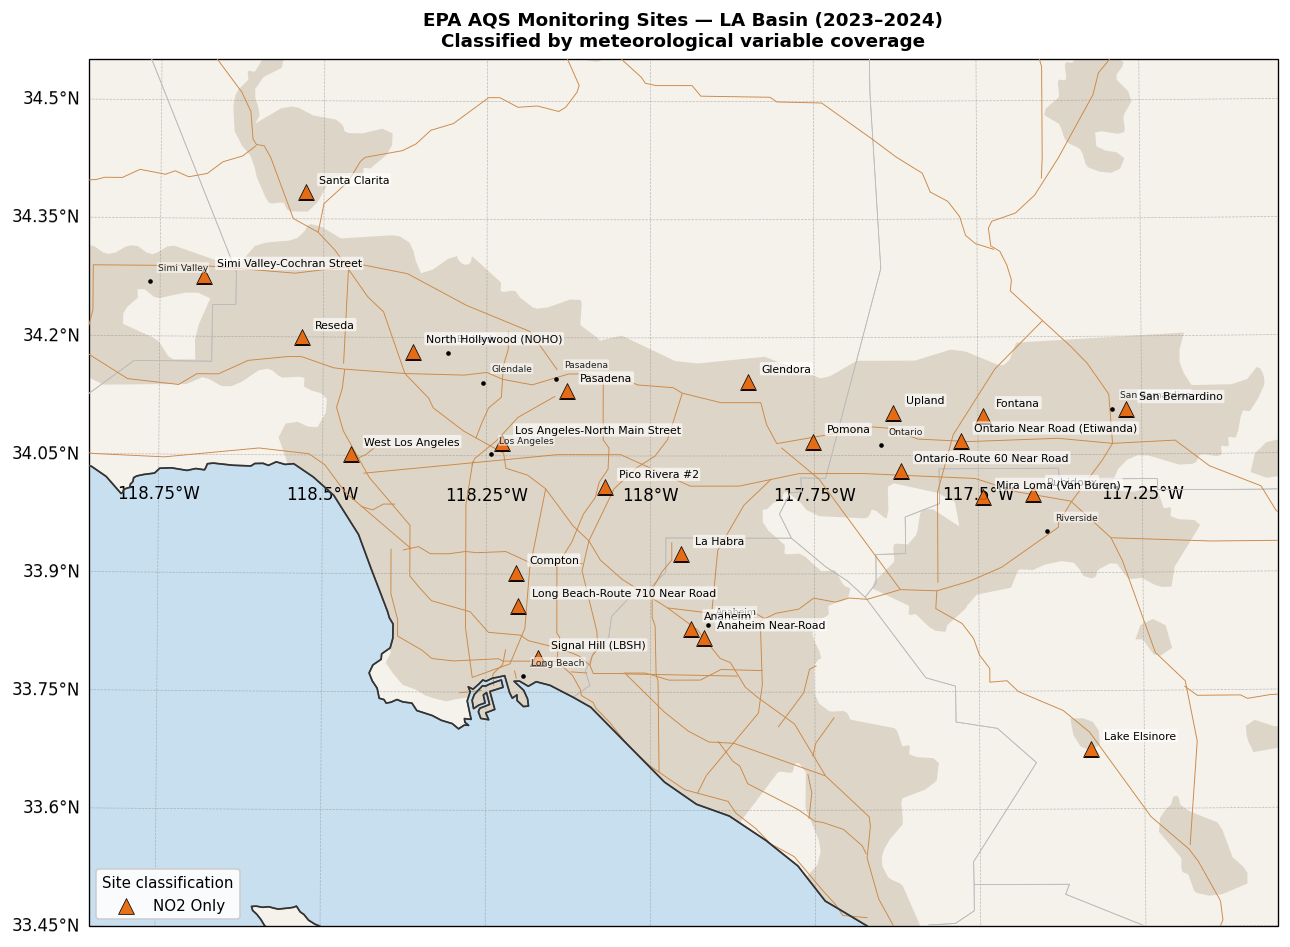

In [4]:
_LA_CITIES = {
    'Los Angeles':    (-118.243, 34.052),
    'Long Beach':     (-118.193, 33.770),
    'Anaheim':        (-117.913, 33.835),
    'Burbank':        (-118.309, 34.181),
    'Glendale':       (-118.255, 34.143),
    'Pasadena':       (-118.144, 34.148),
    'Ontario':        (-117.648, 34.063),
    'Riverside':      (-117.396, 33.953),
    'San Bernardino': (-117.295, 34.108),
    'Simi Valley':    (-118.766, 34.269),
}

def _la_map_axes(fig, spec=111):
    ax = fig.add_subplot(spec, projection=MAP_PROJ)
    ax.set_extent([LON_MIN-.15, LON_MAX+.15, LAT_MIN-.15, LAT_MAX+.15], crs=DATA_CRS)

    # ── Base physical layers ───────────────────────────────────────────────
    ax.add_feature(cfeature.OCEAN.with_scale('10m'),    facecolor='#c8dff0', zorder=0)
    ax.add_feature(cfeature.LAND.with_scale('10m'),     facecolor='#f5f1eb', zorder=1)
    ax.add_feature(cfeature.LAKES.with_scale('10m'),    facecolor='#c8dff0', zorder=2)

    # ── Urban-area footprints ──────────────────────────────────────────────
    ax.add_feature(
        cfeature.NaturalEarthFeature('cultural', 'urban_areas', '10m',
                                     facecolor='#ddd5c8', edgecolor='none'),
        zorder=2)

    # ── Rivers ────────────────────────────────────────────────────────────
    ax.add_feature(
        cfeature.NaturalEarthFeature('physical', 'rivers_lake_centerlines', '10m',
                                     facecolor='none', edgecolor='#6699bb',
                                     linewidth=0.45),
        zorder=3)

    # ── County boundaries ─────────────────────────────────────────────────
    ax.add_feature(
        cfeature.NaturalEarthFeature('cultural', 'admin_2_counties', '10m',
                                     facecolor='none', edgecolor='#bbbbbb',
                                     linewidth=0.45),
        zorder=3)

    # ── Roads (major highways) ────────────────────────────────────────────
    ax.add_feature(
        cfeature.NaturalEarthFeature('cultural', 'roads', '10m',
                                     facecolor='none', edgecolor='#cc8844',
                                     linewidth=0.55),
        zorder=4)

    # ── State borders & coastline ─────────────────────────────────────────
    ax.add_feature(cfeature.STATES.with_scale('10m'),    edgecolor='#666666', linewidth=0.9, zorder=5)
    ax.add_feature(cfeature.COASTLINE.with_scale('10m'), edgecolor='#333333', linewidth=1.0, zorder=6)

    # ── Major city markers & labels ───────────────────────────────────────
    for city, (lon, lat) in _LA_CITIES.items():
        ax.plot(lon, lat, 'k.', ms=3.5, transform=DATA_CRS, zorder=8)
        ax.text(lon + 0.012, lat + 0.012, city,
                fontsize=5.5, color='#222222', transform=DATA_CRS, zorder=9,
                va='bottom', ha='left',
                bbox=dict(boxstyle='round,pad=0.1', fc='white', alpha=0.55, ec='none'))

    gl = ax.gridlines(draw_labels=True, linewidth=0.4, color='grey',
                      alpha=0.5, linestyle='--', crs=DATA_CRS)
    gl.top_labels = gl.right_labels = False
    return ax

palette = {'Complete meteorology':'#1f78b4', 'NO2 Only':'#e66101'}
markers = {'Complete meteorology':'o',       'NO2 Only':'^'}

fig = plt.figure(figsize=(11,8))
ax  = _la_map_axes(fig)
for cls, grp in sites.groupby('classification'):
    ax.scatter(grp['lon'], grp['lat'], color=palette[cls], marker=markers[cls],
               s=90, alpha=0.9, edgecolors='k', linewidths=0.5,
               transform=DATA_CRS, zorder=7, label=cls)
    for _, row in grp.iterrows():
        ax.text(row['lon']+0.02, row['lat']+0.01, str(row['name']).strip(),
                fontsize=6.5, transform=DATA_CRS, zorder=10, va='bottom', ha='left',
                bbox=dict(boxstyle='round,pad=0.15', fc='white', alpha=0.65, ec='none'))
ax.legend(loc='lower left', fontsize=9, framealpha=0.9,
          title='Site classification', title_fontsize=9)
ax.set_title('EPA AQS Monitoring Sites — LA Basin (2023–2024)\nClassified by meteorological variable coverage',
             fontsize=11, fontweight='bold', pad=8)
plt.tight_layout()
fig.savefig(OUT_DIR/'map_site_classification.png', dpi=150, bbox_inches='tight')
plt.show()


## 4 · Map — Max Daily Mean NO₂ per Site (2024)

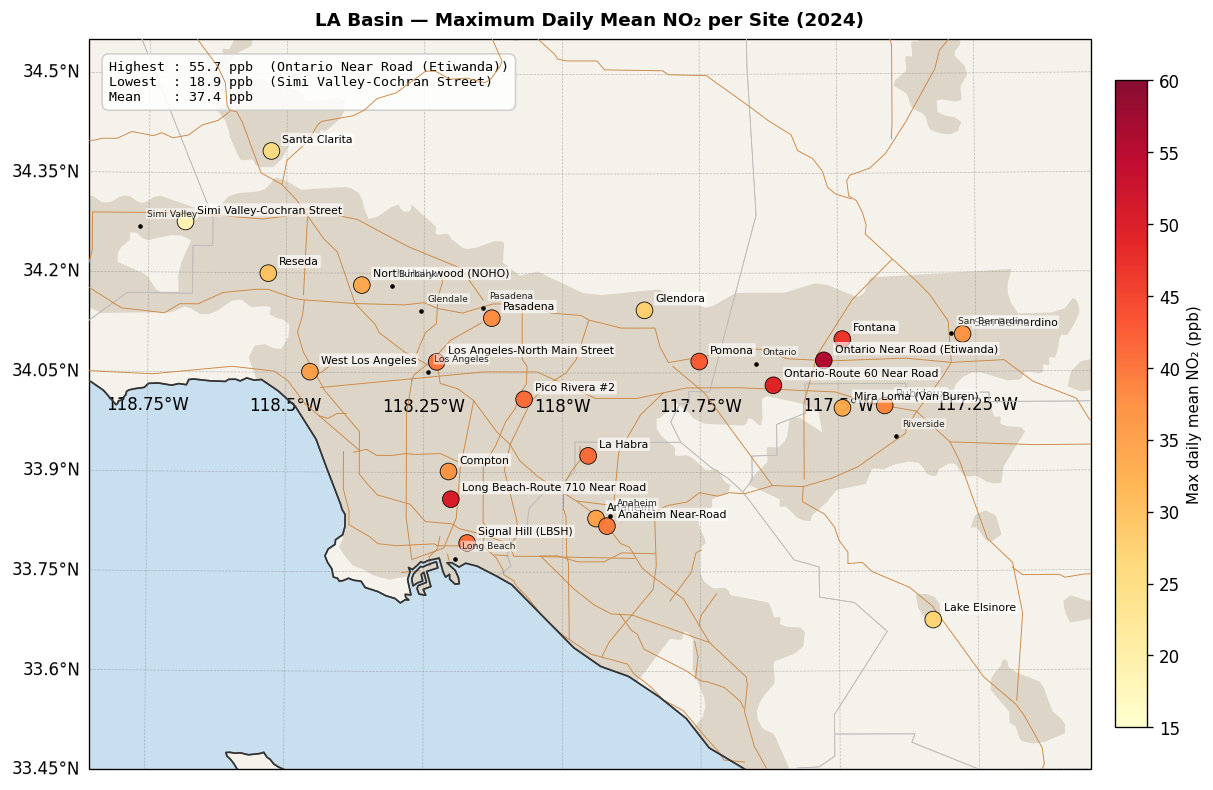

In [5]:
no2_2024 = no2_la[no2_la['Date Local'].dt.year == 2024]
max_no2  = no2_2024.groupby('site_id')['Arithmetic Mean'].max().rename('max_no2')
plot_df  = sites.join(max_no2, how='inner').dropna(subset=['max_no2'])

fig = plt.figure(figsize=(11,8))
ax  = _la_map_axes(fig)
sc  = ax.scatter(plot_df['lon'], plot_df['lat'],
                 c=plot_df['max_no2'], cmap='YlOrRd', vmin=15, vmax=60,
                 s=100, alpha=0.95, edgecolors='k', linewidths=0.5,
                 transform=DATA_CRS, zorder=6)
cbar = plt.colorbar(sc, ax=ax, orientation='vertical', shrink=0.70, pad=0.02)
cbar.set_label('Max daily mean NO\u2082 (ppb)', fontsize=9)
for _, row in plot_df.iterrows():
    ax.text(row['lon']+0.02, row['lat']+0.01, str(row['name']).strip(),
            fontsize=6.5, transform=DATA_CRS, zorder=7, va='bottom', ha='left',
            bbox=dict(boxstyle='round,pad=0.15', fc='white', alpha=0.65, ec='none'))

hi=plot_df['max_no2'].max(); lo=plot_df['max_no2'].min(); mn=plot_df['max_no2'].mean()
hi_s=plot_df.loc[plot_df['max_no2'].idxmax(),'name']; lo_s=plot_df.loc[plot_df['max_no2'].idxmin(),'name']
ax.text(0.02,0.97,f'Highest : {hi:.1f} ppb  ({hi_s})\nLowest  : {lo:.1f} ppb  ({lo_s})\nMean    : {mn:.1f} ppb',
        transform=ax.transAxes, fontsize=8, va='top', ha='left', family='monospace',
        bbox=dict(boxstyle='round,pad=0.5', fc='white', alpha=0.88, ec='#cccccc'))
ax.set_title('LA Basin — Maximum Daily Mean NO\u2082 per Site (2024)', fontsize=11, fontweight='bold', pad=8)
plt.tight_layout()
fig.savefig(OUT_DIR/'map_max_no2_2024.png', dpi=150, bbox_inches='tight')
plt.show()

## 4.5 · Map — Focus Sites (Anaheim, Ontario, Simi Valley)

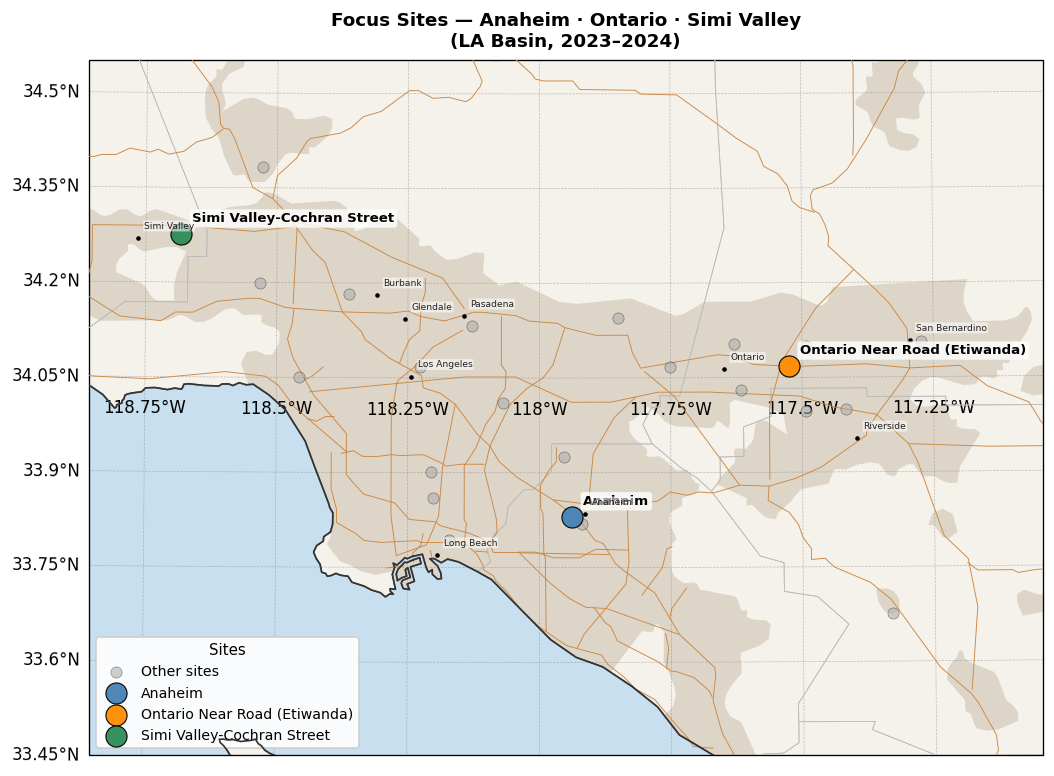

In [6]:
fig = plt.figure(figsize=(9, 7))
ax  = _la_map_axes(fig)

# Add all background sites (grey) for context
other_sites = sites[~sites['name'].isin(FOCUS_SITES)]
ax.scatter(other_sites['lon'], other_sites['lat'],
           color='#aaaaaa', s=45, alpha=0.55, edgecolors='k', linewidths=0.3,
           transform=DATA_CRS, zorder=5, label='Other sites')

# Highlight the 3 focus sites
for site_name, color in zip(FOCUS_SITES, SITE_COLORS):
    mask = sites['name'].str.contains(site_name, case=False, na=False, regex=False)
    if not mask.any():
        print(f'  [skip] {site_name}')
        continue
    row = sites.loc[mask].iloc[0]
    ax.scatter(row['lon'], row['lat'],
               color=color, s=160, alpha=0.95, edgecolors='k', linewidths=0.7,
               transform=DATA_CRS, zorder=7, label=row['name'])
    ax.text(row['lon'] + 0.022, row['lat'] + 0.014, str(row['name']).strip(),
            fontsize=8, fontweight='bold', transform=DATA_CRS, zorder=8,
            va='bottom', ha='left',
            bbox=dict(boxstyle='round,pad=0.2', fc='white', alpha=0.80, ec='none'))

ax.legend(loc='lower left', fontsize=8.5, framealpha=0.9,
          title='Sites', title_fontsize=9)
ax.set_title('Focus Sites — Anaheim · Ontario · Simi Valley\n(LA Basin, 2023–2024)',
             fontsize=11, fontweight='bold', pad=8)
plt.tight_layout()
fig.savefig(OUT_DIR / 'map_focus_sites.png', dpi=150, bbox_inches='tight')
plt.show()


## 5 · Time Series — Anaheim, Ontario, Simi Valley

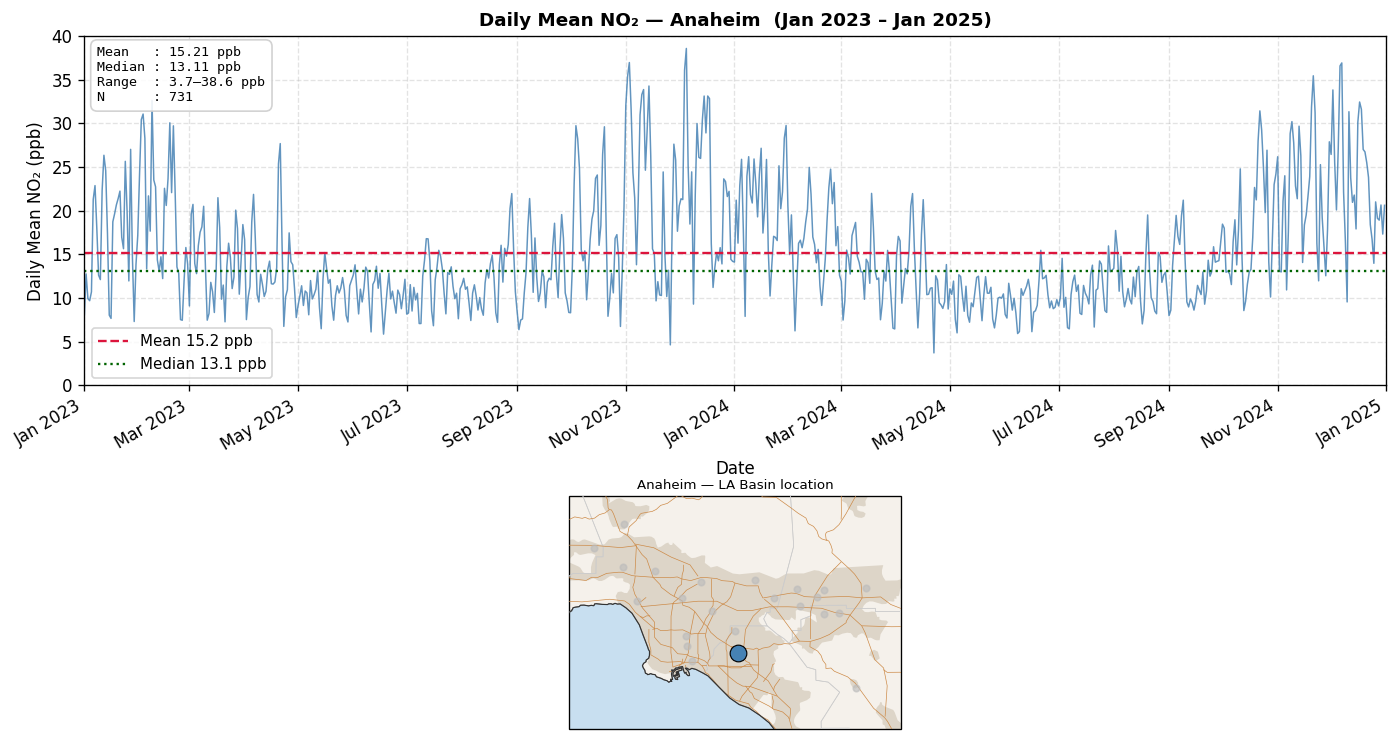

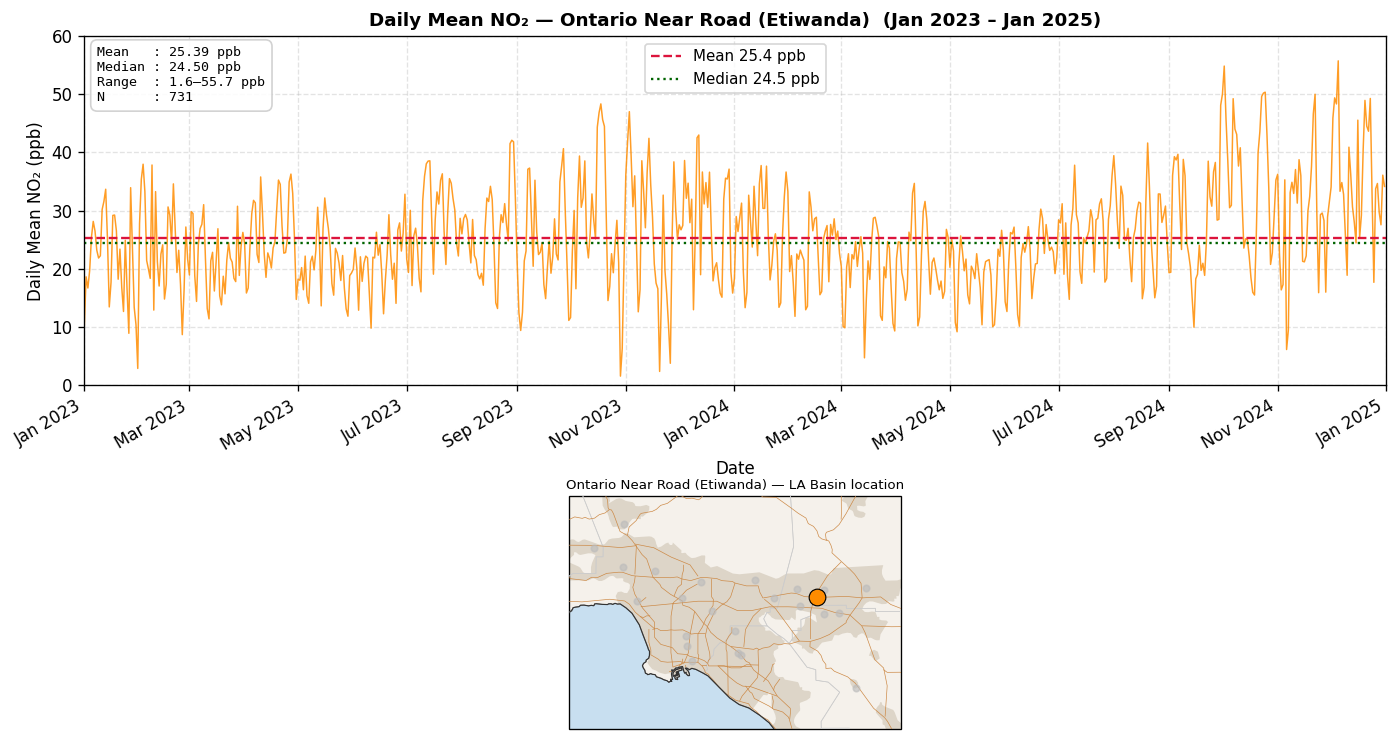

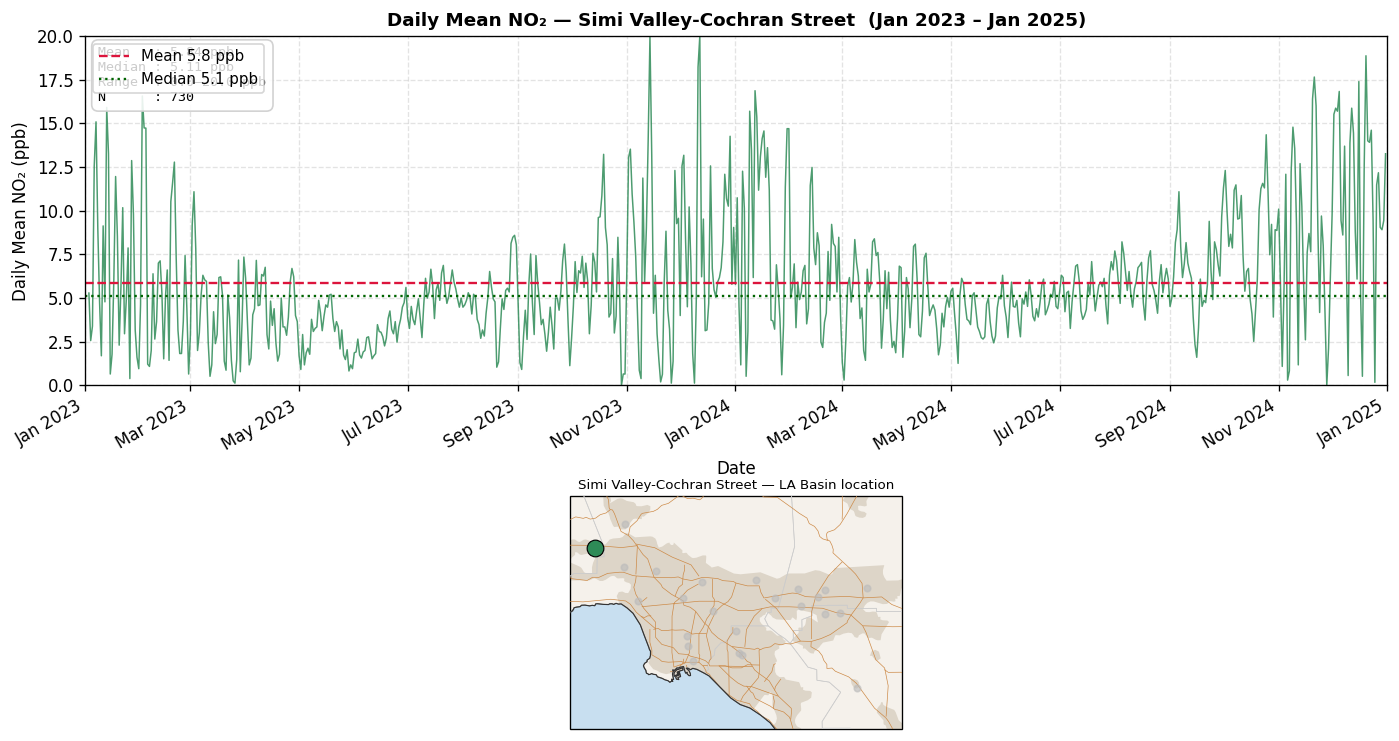

In [7]:
def _get_site_series(no2_la, site_name):
    mask = no2_la['Local Site Name'].str.contains(site_name, case=False, na=False, regex=False)
    if not mask.any(): raise KeyError(f'Site not found: {site_name!r}')
    s = no2_la.loc[mask].groupby('Date Local')['Arithmetic Mean'].mean()
    return pd.to_datetime(s.index).to_frame(index=False).set_index('Date Local').squeeze().__class__(
        s.values, index=pd.to_datetime(s.index)).sort_index()

def _style_inset(ax_map, site_lon, site_lat, dot_color):
    """Apply enhanced Cartopy features to a small inset/panel map."""
    ax_map.set_extent([LON_MIN-.1, LON_MAX+.1, LAT_MIN-.1, LAT_MAX+.1], crs=DATA_CRS)
    ax_map.add_feature(cfeature.OCEAN.with_scale('10m'),     facecolor='#c8dff0', zorder=0)
    ax_map.add_feature(cfeature.LAND.with_scale('10m'),      facecolor='#f5f1eb', zorder=1)
    ax_map.add_feature(cfeature.LAKES.with_scale('10m'),     facecolor='#c8dff0', zorder=2)
    ax_map.add_feature(
        cfeature.NaturalEarthFeature('cultural', 'urban_areas', '10m',
                                     facecolor='#ddd5c8', edgecolor='none'), zorder=2)
    ax_map.add_feature(
        cfeature.NaturalEarthFeature('cultural', 'admin_2_counties', '10m',
                                     facecolor='none', edgecolor='#cccccc',
                                     linewidth=0.4), zorder=3)
    ax_map.add_feature(
        cfeature.NaturalEarthFeature('cultural', 'roads', '10m',
                                     facecolor='none', edgecolor='#cc8844',
                                     linewidth=0.4), zorder=4)
    ax_map.add_feature(cfeature.STATES.with_scale('10m'),    edgecolor='#888888', linewidth=0.5, zorder=5)
    ax_map.add_feature(cfeature.COASTLINE.with_scale('10m'), edgecolor='#333333', linewidth=0.7, zorder=6)
    ax_map.scatter(sites['lon'], sites['lat'],
                   color='#bbbbbb', s=15, alpha=0.6, transform=DATA_CRS, zorder=7)
    ax_map.scatter([site_lon], [site_lat],
                   color=dot_color, s=100, edgecolors='k', linewidths=0.7,
                   transform=DATA_CRS, zorder=8)

full_idx = pd.date_range('2023-01-01','2025-01-01', freq='D')

for site, color in zip(FOCUS_SITES, SITE_COLORS):
    try:
        mask = no2_la['Local Site Name'].str.contains(site, case=False, na=False, regex=False)
        s = no2_la.loc[mask].groupby('Date Local')['Arithmetic Mean'].mean()
        s.index = pd.to_datetime(s.index)
        series = s.sort_index().reindex(full_idx)
    except Exception as e:
        print(f'  [skip] {e}'); continue

    ylim=SITE_YLIMS.get(site,(0,None)); mean_v=series.mean(); med_v=series.median()
    rng=f'{series.min():.1f}–{series.max():.1f}'; n=int(series.notna().sum())
    site_row = sites[sites['name'].str.contains(site, case=False, na=False, regex=False)]
    has_map  = not site_row.empty

    fig = plt.figure(figsize=(14, 7.5 if has_map else 4.5))
    if has_map:
        gs  = fig.add_gridspec(2, 3, height_ratios=[3, 2], hspace=0.38)
        ax  = fig.add_subplot(gs[0, :])
        ax_map = fig.add_subplot(gs[1, 1], projection=MAP_PROJ)
    else:
        ax = fig.add_subplot(111)

    ax.plot(series.index, series.values, color=color, lw=0.9, alpha=0.85)
    ax.axhline(mean_v, color='crimson',   lw=1.4, ls='--', label=f'Mean {mean_v:.1f} ppb')
    ax.axhline(med_v,  color='darkgreen', lw=1.4, ls=':',  label=f'Median {med_v:.1f} ppb')
    ax.set_ylim(*ylim); ax.set_xlim(full_idx[0], full_idx[-1])
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')
    ax.set_xlabel('Date'); ax.set_ylabel('Daily Mean NO\u2082 (ppb)')
    ax.set_title(f'Daily Mean NO\u2082 — {site}  (Jan 2023 – Jan 2025)', fontsize=11, fontweight='bold')
    ax.legend(fontsize=9); ax.grid(True, linestyle='--', alpha=0.35)
    ax.text(0.01,0.97, f'Mean   : {mean_v:.2f} ppb\nMedian : {med_v:.2f} ppb\nRange  : {rng} ppb\nN      : {n:,}',
            transform=ax.transAxes, fontsize=8, va='top', ha='left', family='monospace',
            bbox=dict(boxstyle='round,pad=0.5', fc='white', alpha=0.88, ec='#cccccc'))

    if has_map:
        _style_inset(ax_map, site_row.iloc[0]['lon'], site_row.iloc[0]['lat'], color)
        ax_map.set_title(f'{site} — LA Basin location', fontsize=8, pad=4)

    plt.tight_layout()
    fig.savefig(OUT_DIR/f'ts_{site.split()[0].lower()}.png', dpi=150, bbox_inches='tight')
    plt.show()


## 6 · Histograms — Anaheim, Ontario, Simi Valley

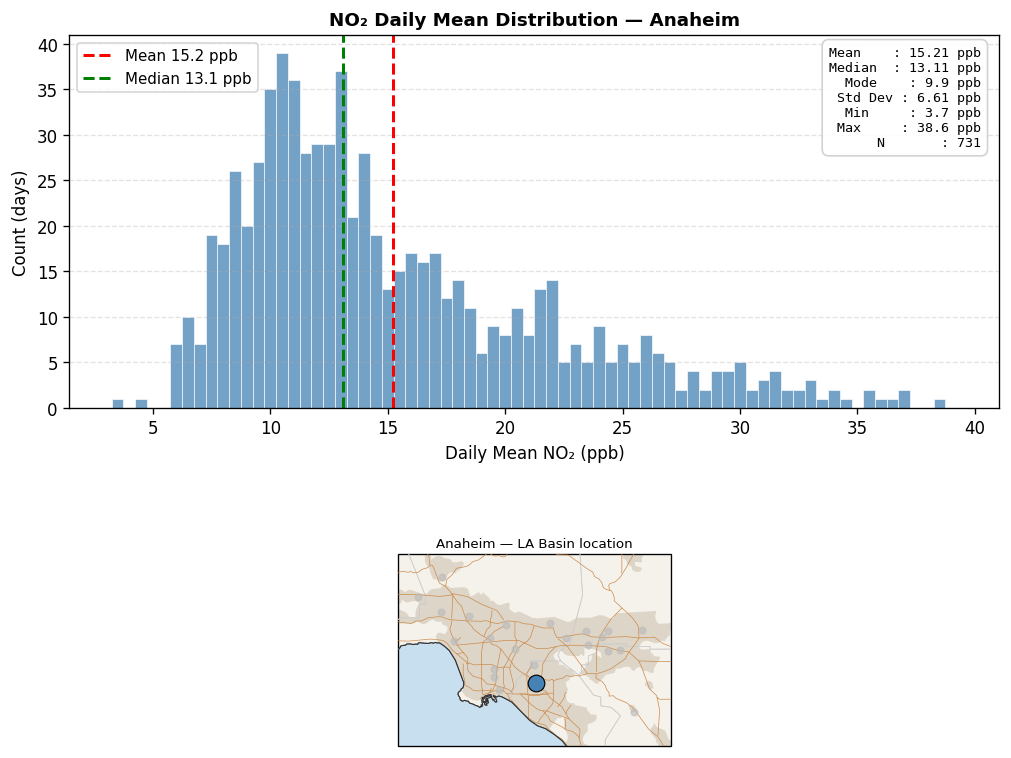

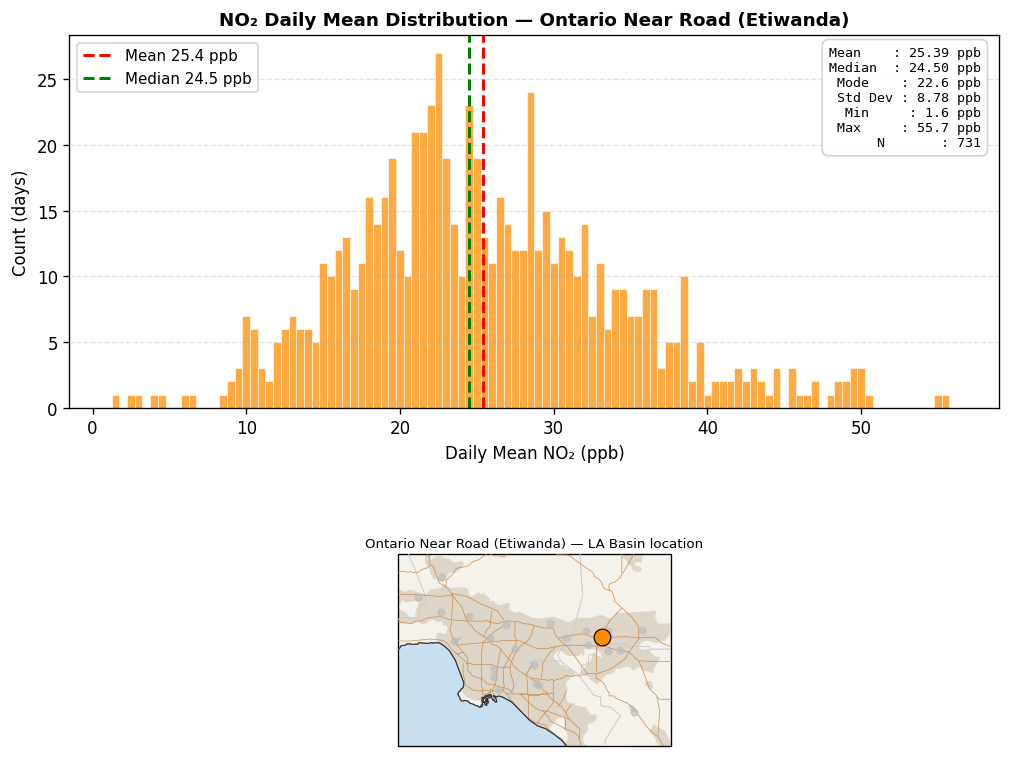

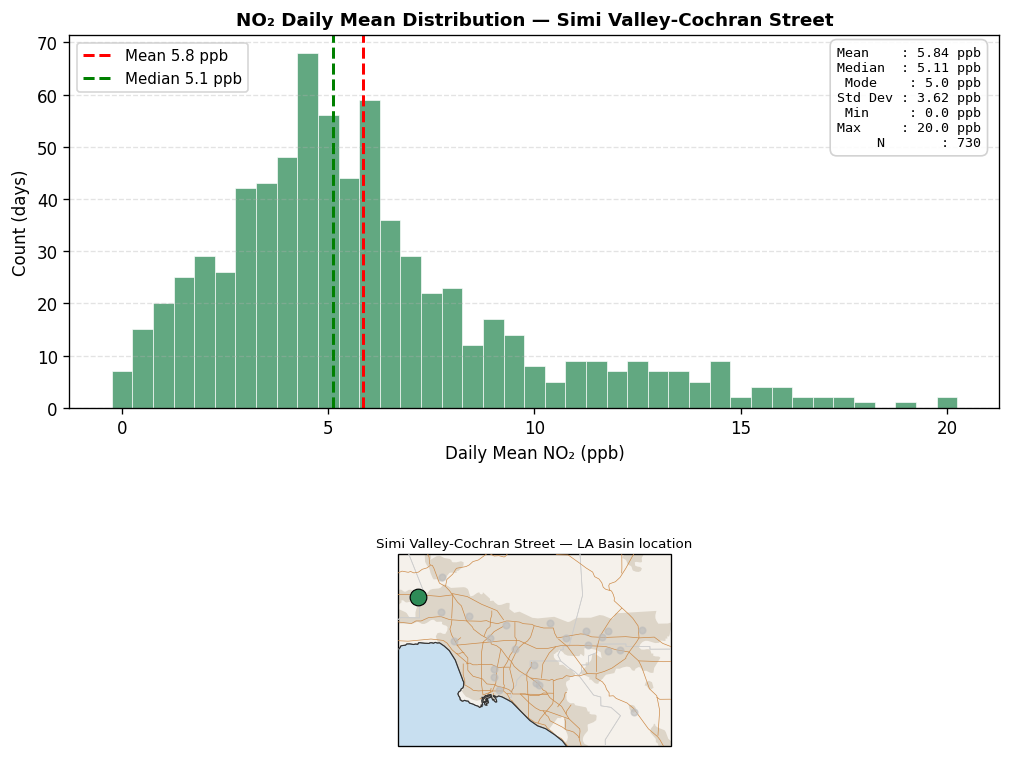

In [8]:
BIN = 0.5

for site, color in zip(FOCUS_SITES, SITE_COLORS):
    mask = no2_la['Local Site Name'].str.contains(site, case=False, na=False, regex=False)
    if not mask.any(): print(f'  [skip] {site}'); continue
    s = no2_la.loc[mask].groupby('Date Local')['Arithmetic Mean'].mean()
    s.index = pd.to_datetime(s.index)
    series = s.sort_index().dropna()

    mean_v=series.mean(); med_v=series.median()
    mode_v=float(stats.mode(series.round(1).values, keepdims=True).mode[0])
    std_v=series.std(); min_v=series.min(); max_v=series.max(); n=len(series)

    lo=np.floor(min_v/BIN)*BIN; hi=np.ceil(max_v/BIN)*BIN
    bins=np.arange(lo-BIN/2, hi+BIN, BIN)

    site_row = sites[sites['name'].str.contains(site, case=False, na=False, regex=False)]
    has_map  = not site_row.empty

    fig = plt.figure(figsize=(10, 8 if has_map else 5))
    if has_map:
        gs  = fig.add_gridspec(2, 3, height_ratios=[3, 2], hspace=0.38)
        ax  = fig.add_subplot(gs[0, :])
        ax_map = fig.add_subplot(gs[1, 1], projection=MAP_PROJ)
    else:
        ax = fig.add_subplot(111)

    ax.hist(series.values, bins=bins, color=color, alpha=0.75, edgecolor='white', linewidth=0.5)
    ax.axvline(mean_v, color='red',   lw=1.8, ls='--', label=f'Mean {mean_v:.1f} ppb')
    ax.axvline(med_v,  color='green', lw=1.8, ls='--', label=f'Median {med_v:.1f} ppb')
    ax.set_xlabel('Daily Mean NO\u2082 (ppb)'); ax.set_ylabel('Count (days)')
    ax.set_title(f'NO\u2082 Daily Mean Distribution — {site}', fontsize=11, fontweight='bold')
    ax.legend(fontsize=9); ax.grid(True, axis='y', linestyle='--', alpha=0.35)
    ax.text(0.98,0.97,
            f'Mean    : {mean_v:.2f} ppb\nMedian  : {med_v:.2f} ppb\nMode    : {mode_v:.1f} ppb\n'
            f'Std Dev : {std_v:.2f} ppb\nMin     : {min_v:.1f} ppb\nMax     : {max_v:.1f} ppb\nN       : {n:,}',
            transform=ax.transAxes, fontsize=8, va='top', ha='right', family='monospace',
            bbox=dict(boxstyle='round,pad=0.5', fc='white', alpha=0.88, ec='#cccccc'))

    if has_map:
        _style_inset(ax_map, site_row.iloc[0]['lon'], site_row.iloc[0]['lat'], color)
        ax_map.set_title(f'{site} — LA Basin location', fontsize=8, pad=4)

    plt.tight_layout()
    fig.savefig(OUT_DIR/f'hist_{site.split()[0].lower()}.png', dpi=150, bbox_inches='tight')
    plt.show()


## 7 · Baseline Models — Anaheim

In [9]:
# Build Anaheim series
mask_a = no2_la['Local Site Name'].str.contains('Anaheim', case=False, na=False, regex=False)
s_a = no2_la.loc[mask_a].groupby('Date Local')['Arithmetic Mean'].mean()
s_a.index = pd.to_datetime(s_a.index)
s_a = s_a.sort_index()

full_a   = pd.date_range(s_a.index.min(), s_a.index.max(), freq='D')
obs      = s_a.reindex(full_a).values.astype(float)
dates    = full_a

obs_clean      = obs[~np.isnan(obs)]
overall_mean   = float(np.mean(obs_clean))
overall_median = float(np.median(obs_clean))
overall_mode   = float(stats.mode(np.round(obs_clean,1), keepdims=True).mode[0])
std_obs        = float(np.std(obs_clean))

persistence      = np.roll(obs, 1)
persistence[0]   = np.nan

models = {
    'Mean Model':        np.full_like(obs, overall_mean),
    'Median Model':      np.full_like(obs, overall_median),
    'Mode Model':        np.full_like(obs, overall_mode),
    'Persistence Model': persistence,
}
pred_labels = {
    'Mean Model':        f'{overall_mean:.2f} ppb (constant)',
    'Median Model':      f'{overall_median:.2f} ppb (constant)',
    'Mode Model':        f'{overall_mode:.1f} ppb (constant)',
    'Persistence Model': "Yesterday's observed value",
}
print(f'Overall mean={overall_mean:.2f}  median={overall_median:.2f}  mode={overall_mode:.1f}  std={std_obs:.2f} ppb')

Overall mean=15.21  median=13.11  mode=9.9  std=6.60 ppb


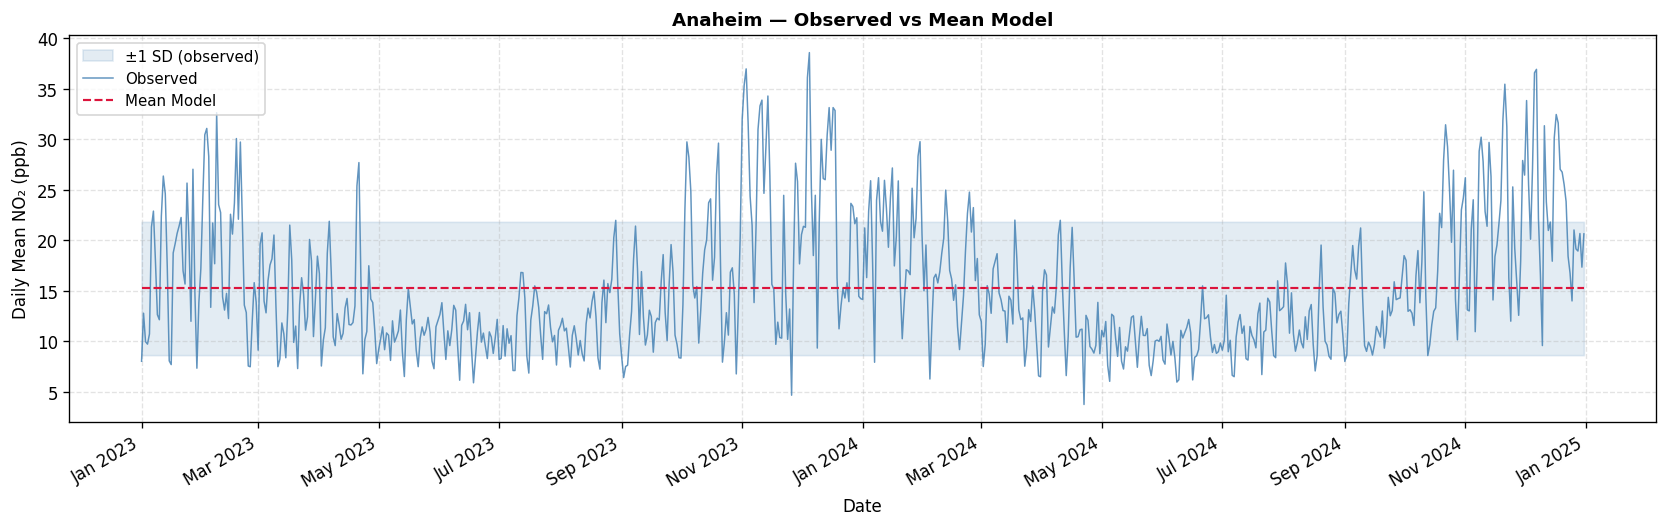

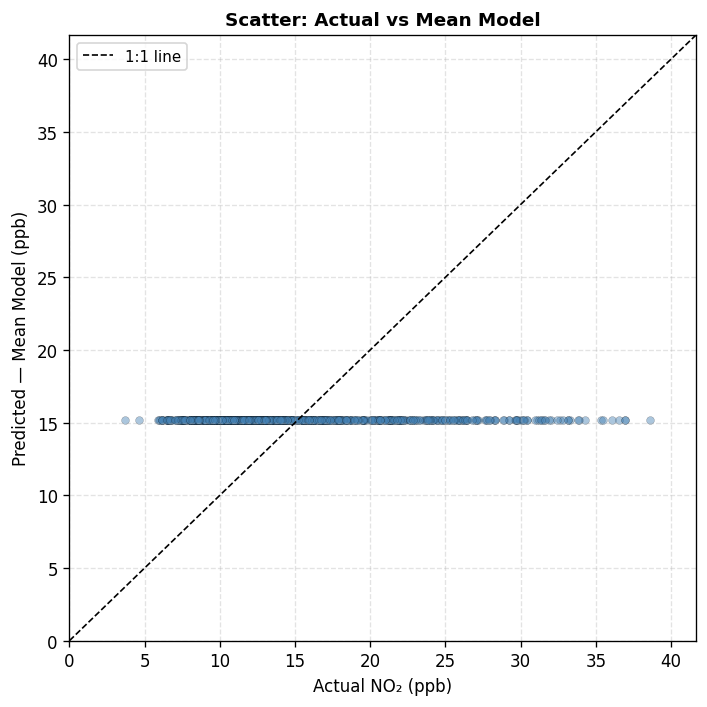

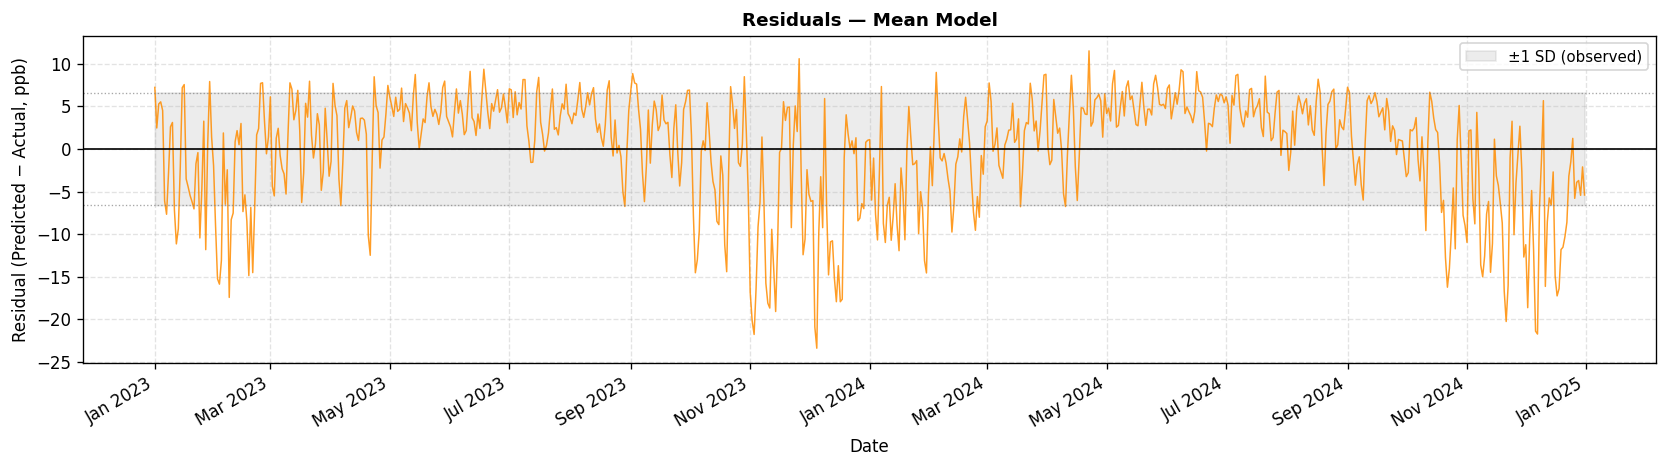

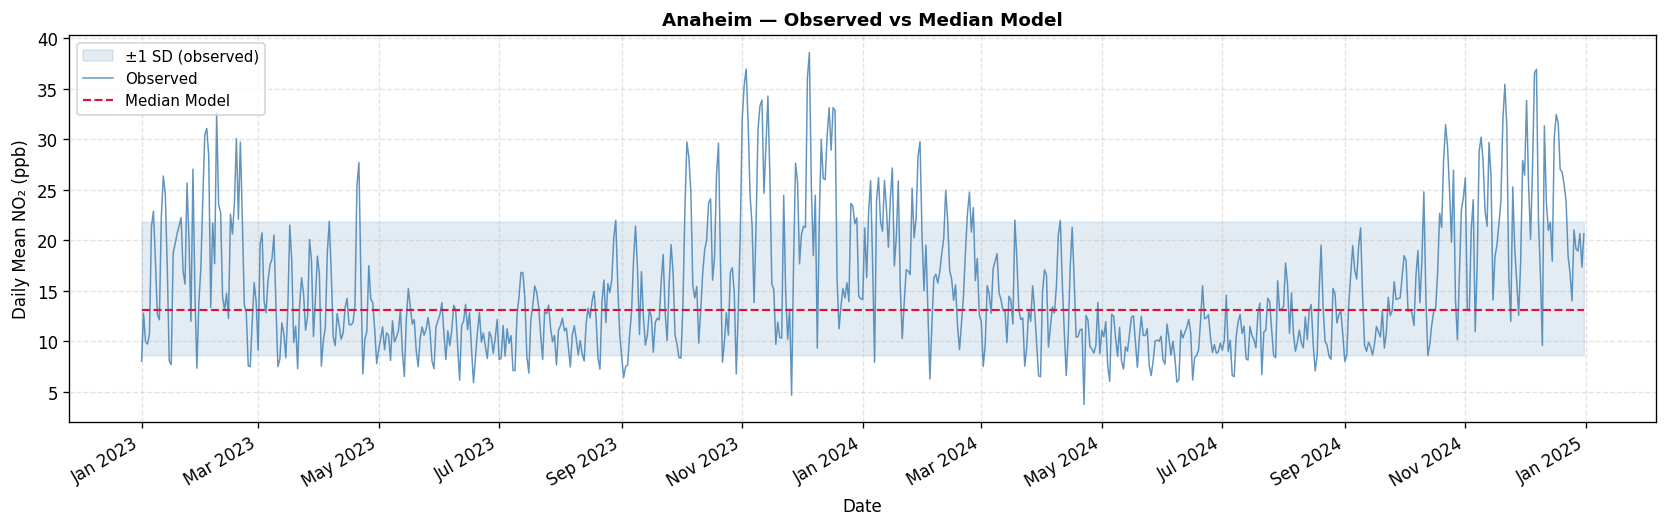

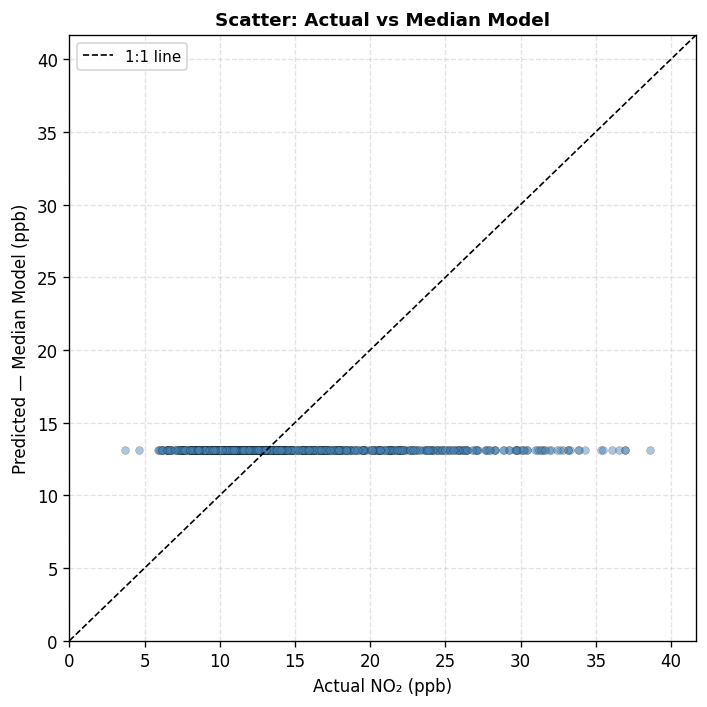

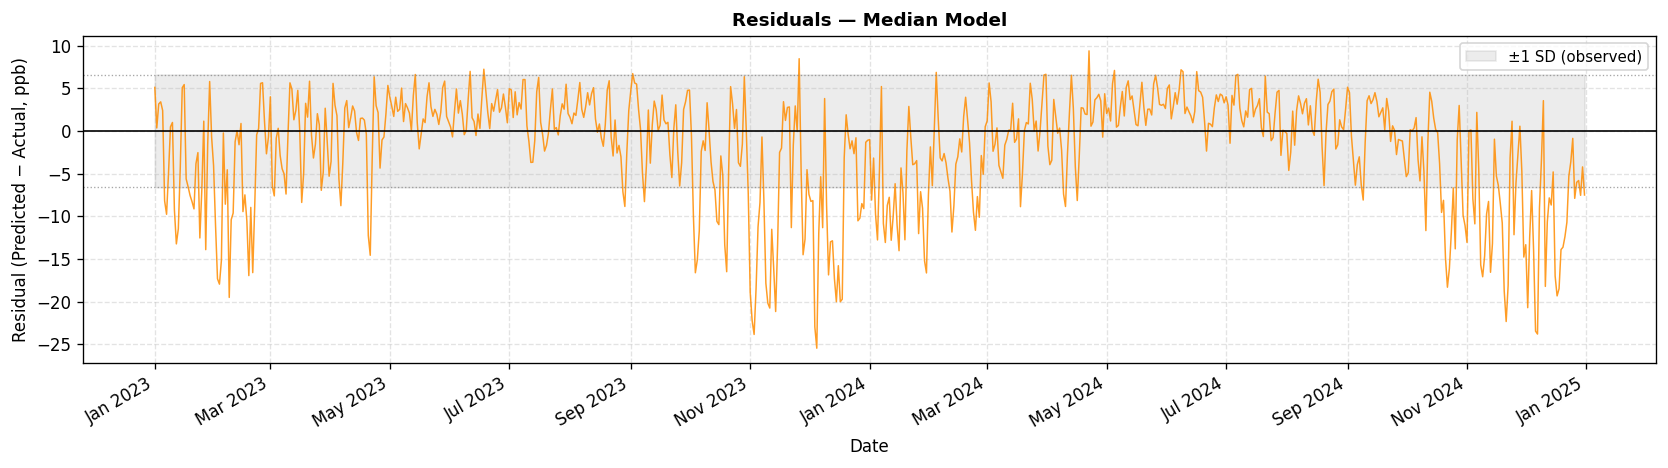

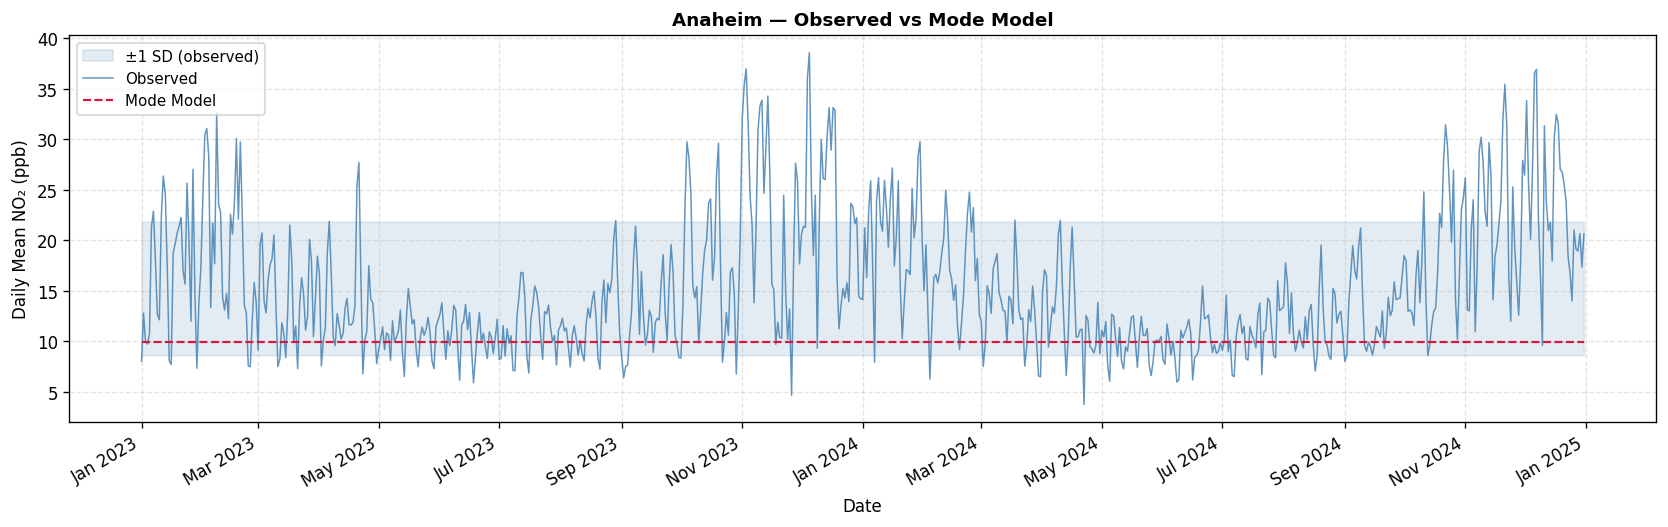

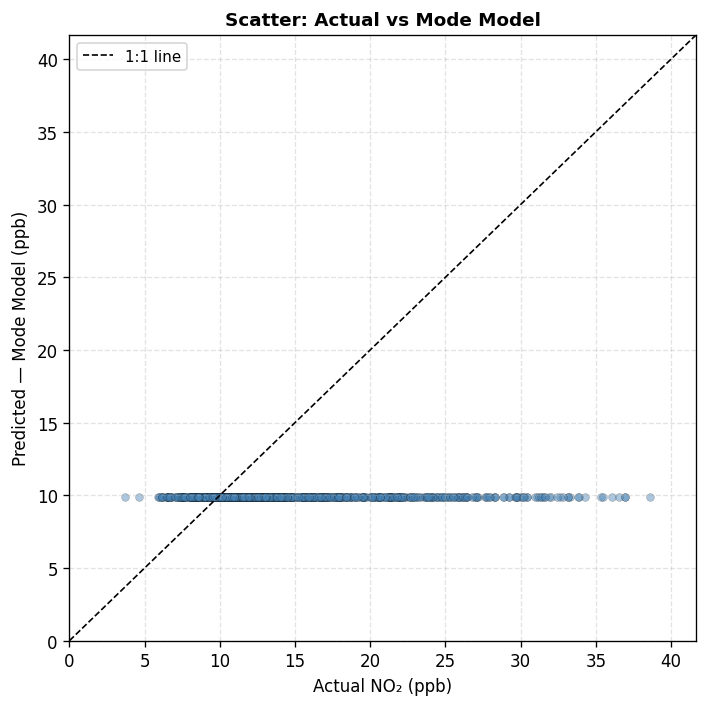

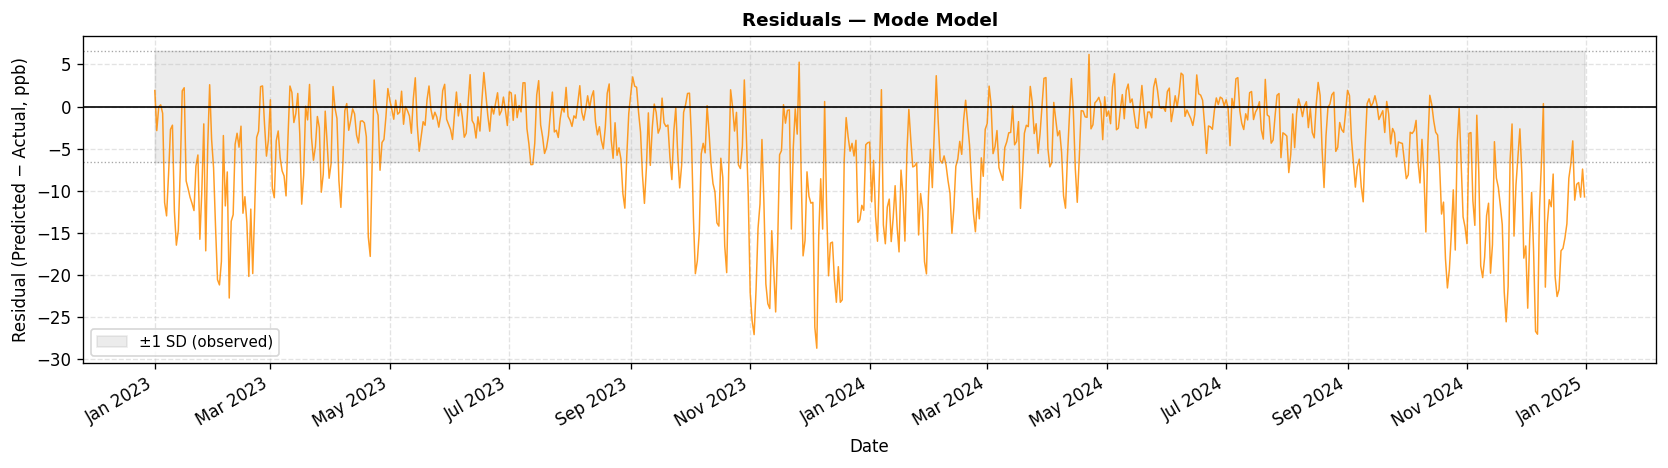

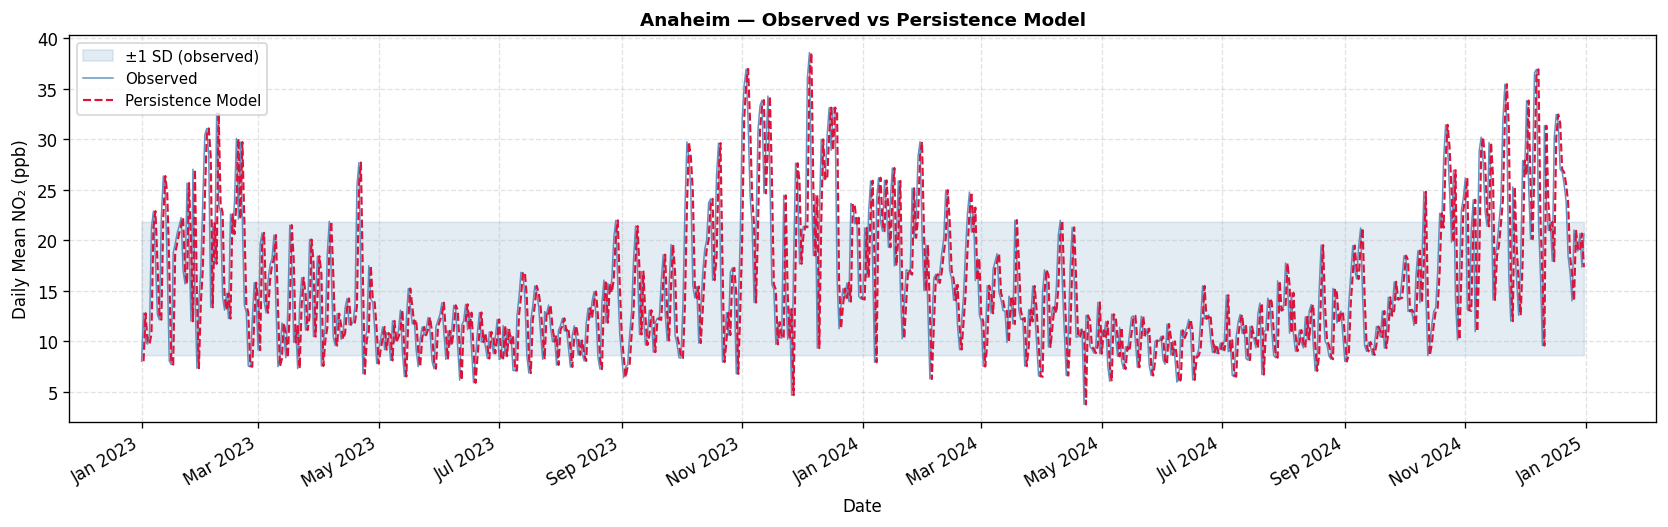

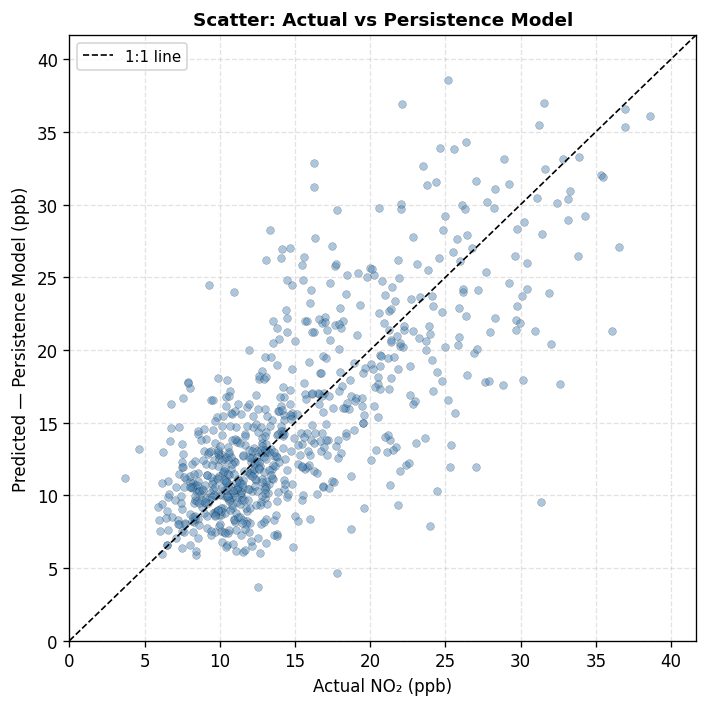

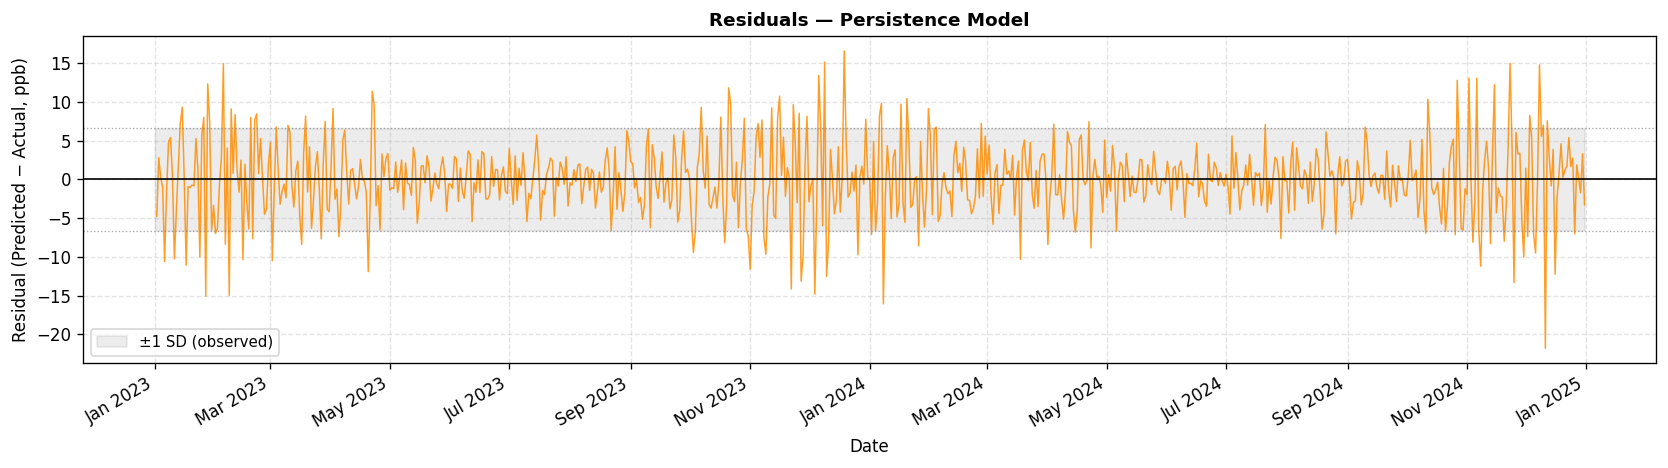

In [10]:
def compute_metrics(obs, pred):
    mask = ~(np.isnan(obs)|np.isnan(pred))
    yt,yp = obs[mask],pred[mask]
    return {'RMSE':np.sqrt(mean_squared_error(yt,yp)), 'MAE':mean_absolute_error(yt,yp), 'R2':r2_score(yt,yp)}

results = []
best_for = {'Mean Model':'Lowest RMSE among constant baselines',
            'Median Model':'Lowest MAE among constant baselines',
            'Mode Model':'Most-frequent-value baseline',
            'Persistence Model':'Best overall (RMSE, MAE & R²)'}

for model_name, pred in models.items():
    tag = model_name.lower().replace(' ','_')

    # ── Time series plot ──────────────────────────────────────────────────
    fig,ax = plt.subplots(figsize=(14,4.5))
    ax.fill_between(dates, overall_mean-std_obs, overall_mean+std_obs,
                    color='steelblue', alpha=0.15, label='±1 SD (observed)')
    ax.plot(dates, obs,  color='steelblue', lw=0.9, alpha=0.85, label='Observed')
    ax.plot(dates, pred, color='crimson',   lw=1.3, ls='--',    label=model_name)
    ax.set_xlabel('Date'); ax.set_ylabel('Daily Mean NO\u2082 (ppb)')
    ax.set_title(f'Anaheim — Observed vs {model_name}', fontsize=11, fontweight='bold')
    ax.legend(fontsize=9); ax.grid(True, linestyle='--', alpha=0.35)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')
    plt.tight_layout()
    fig.savefig(OUT_DIR/f'model_ts_{tag}.png', dpi=150, bbox_inches='tight')
    plt.show()

    # ── Scatter plot ──────────────────────────────────────────────────────
    mask = ~(np.isnan(obs)|np.isnan(pred))
    yt,yp = obs[mask],pred[mask]
    lim = max(np.nanmax(yt),np.nanmax(yp))*1.08
    fig,ax = plt.subplots(figsize=(6,6))
    ax.scatter(yt,yp, color='steelblue', alpha=0.45, s=22, edgecolors='k', linewidths=0.2)
    ax.plot([0,lim],[0,lim],'k--', lw=1.0, label='1:1 line')
    ax.set_xlim(0,lim); ax.set_ylim(0,lim)
    ax.set_xlabel('Actual NO\u2082 (ppb)'); ax.set_ylabel(f'Predicted — {model_name} (ppb)')
    ax.set_title(f'Scatter: Actual vs {model_name}', fontsize=11, fontweight='bold')
    ax.legend(fontsize=9); ax.grid(True, linestyle='--', alpha=0.35)
    plt.tight_layout()
    fig.savefig(OUT_DIR/f'model_scatter_{tag}.png', dpi=150, bbox_inches='tight')
    plt.show()

    # ── Residuals plot ────────────────────────────────────────────────────
    residuals = pred - obs
    fig,ax = plt.subplots(figsize=(14,4))
    ax.fill_between(dates, -std_obs, std_obs, color='grey', alpha=0.15, label='±1 SD (observed)')
    ax.plot(dates, residuals, color='darkorange', lw=0.9, alpha=0.85)
    ax.axhline(0, color='black', lw=1.0)
    ax.axhline( std_obs, color='grey', lw=0.8, ls=':', alpha=0.7)
    ax.axhline(-std_obs, color='grey', lw=0.8, ls=':', alpha=0.7)
    ax.set_xlabel('Date'); ax.set_ylabel('Residual (Predicted − Actual, ppb)')
    ax.set_title(f'Residuals — {model_name}', fontsize=11, fontweight='bold')
    ax.legend(fontsize=9); ax.grid(True, linestyle='--', alpha=0.35)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')
    plt.tight_layout()
    fig.savefig(OUT_DIR/f'model_residuals_{tag}.png', dpi=150, bbox_inches='tight')
    plt.show()

    m = compute_metrics(obs, pred)
    results.append({'Model':model_name, 'Prediction':pred_labels[model_name],
                    'RMSE':round(m['RMSE'],3), 'MAE':round(m['MAE'],3),
                    'R²':round(m['R2'],4), 'Best for':best_for[model_name]})

## 8 · Summary Table

In [11]:
summary = pd.DataFrame(results)
summary.to_csv(OUT_DIR/'baseline_model_summary.csv', index=False)
print('Saved → baseline_model_summary.csv\n')
summary

Saved → baseline_model_summary.csv



,Model,Prediction,RMSE,MAE,R²,Best for
0,Mean Model,15.21 ppb (constant),6.602,5.257,0.0000,Lowest RMSE among constant baselines
1,Median Model,13.11 ppb (constant),6.929,4.997,-0.1015,Lowest MAE among constant baselines
2,Mode Model,9.9 ppb (constant),8.472,5.955,-0.6467,Most-frequent-value baseline
3,Persistence Model,Yesterday's observed value,4.770,3.528,0.4779,"Best overall (RMSE, MAE & R²)"
